# 08 - Model Comparison, Leakage Mitigation & Fairness
**AI Forensic Triage Tool: Predicting Shooting Incidents in Boston**  
**Capstone Project — DSE 6311**  
**Author:** Ricardo Orellana  

**Goal:** Compare XGBoost, RandomForest, and LightGBM; test for data leakage; evaluate fairness; generate final model and Tableau-ready file.

In [32]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Notebook 08 started - Model Comparison, Leakage Mitigation & Fairness")

✅ Notebook 08 started - Model Comparison, Leakage Mitigation & Fairness


In [33]:
# ================== ROBUST PATHS ==================
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "src":
    REPO_ROOT = CURRENT_DIR.parent
elif CURRENT_DIR.name == "notebooks":
    REPO_ROOT = CURRENT_DIR.parent
else:
    REPO_ROOT = CURRENT_DIR

# Add the src/ folder to Python path (this fixes the import error)
sys.path.append(str(REPO_ROOT / "src"))

print(f"✅ REPO_ROOT set to: {REPO_ROOT}")
print("✅ src/ folder added to Python path")

from feature_engineering import create_time_features, create_violent_flag
from data_utils import load_data

✅ REPO_ROOT set to: C:\Users\richa\Documents\GitHub\AI-Forensics-Boston-Capstone
✅ src/ folder added to Python path


In [34]:
# ================== LOAD DATA ==================
df = load_data("crime_features.csv")
print(f"Loaded {len(df):,} rows")

Loaded 239,371 rows


In [35]:
# ================== FEATURE ENGINEERING ==================
df = create_time_features(df)
df = create_violent_flag(df)

# District-level poverty rate (ACS proxy)
poverty_map = {
    'B3': 0.28, 'B2': 0.25, 'C11': 0.24, 'E18': 0.22, 'Unknown': 0.20,
    'E13': 0.21, 'E5': 0.18, 'A15': 0.17, 'C6': 0.16, 'D4': 0.15,
    'A7': 0.14, 'D14': 0.13, 'A1': 0.12, 'External': 0.10, 'Outside of': 0.10
}
df['poverty_rate'] = df['DISTRICT'].map(poverty_map).fillna(0.20)

# One-hot encode DISTRICT
district_dummies = pd.get_dummies(df['DISTRICT'], prefix='district')
df = pd.concat([df, district_dummies], axis=1)

print("✅ Feature engineering completed")

✅ 'hour' column already exists - skipping time feature creation
✅ Feature engineering completed


In [36]:
# ================== PREPARE FEATURES & TARGET ==================
feature_cols = ['hour', 'is_night', 'is_weekend', 'is_violent', 'poverty_rate'] + \
               [col for col in df.columns if col.startswith('district_')]

X = df[feature_cols]
y = df['SHOOTING']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"✅ scale_pos_weight = {scale_pos_weight:.2f}")

✅ scale_pos_weight = 141.59


In [37]:
# ================== TRAIN THREE MODELS ==================
models = {}

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='aucpr'
)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model

# RandomForest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
models['RandomForest'] = rf_model

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)
models['LightGBM'] = lgb_model

print("✅ Three models trained (XGBoost, RandomForest, LightGBM)")

✅ Three models trained (XGBoost, RandomForest, LightGBM)


In [38]:
# ================== MODEL COMPARISON ==================
print("\n=== Model Comparison (Test Set) ===")
results = {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)
    results[name] = pr_auc
    print(f"{name:12} → PR-AUC: {pr_auc:.4f}")


=== Model Comparison (Test Set) ===
XGBoost      → PR-AUC: 0.0391
RandomForest → PR-AUC: 0.0377
LightGBM     → PR-AUC: 0.0387


In [39]:
# ================== LEAKAGE TEST ==================
feature_cols_no_leak = ['hour', 'is_night', 'is_weekend', 'poverty_rate'] + \
                       [col for col in X.columns if col.startswith('district_')]

X_train_nl = X_train[feature_cols_no_leak]
X_test_nl = X_test[feature_cols_no_leak]

final_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='aucpr'
)
final_model.fit(X_train_nl, y_train)

proba_nl = final_model.predict_proba(X_test_nl)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, proba_nl)
pr_auc_nl = auc(recall, precision)
print(f"\nLeakage Test (without is_violent) PR-AUC: {pr_auc_nl:.4f}")


Leakage Test (without is_violent) PR-AUC: 0.0378


In [40]:
# Save final model
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
final_model.save_model(str(MODELS_DIR / "xgboost_shooting_model_final.json"))
print("✅ Final model saved as xgboost_shooting_model_final.json")

✅ Final model saved as xgboost_shooting_model_final.json


In [41]:
# ================== FINAL PREDICTIONS FOR TABLEAU ==================
print("\n=== Generating final predictions + SHAP for Tableau ===")

feature_cols_final = ['hour', 'is_night', 'is_weekend', 'poverty_rate'] + \
                     [col for col in X.columns if col.startswith('district_')]

X_final = X[feature_cols_final].copy()

dff = X_final.copy()
dff['predicted_prob'] = final_model.predict_proba(X_final)[:, 1]
dff['predicted'] = (dff['predicted_prob'] >= 0.5).astype(int)

# SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_final)

for i, col in enumerate(feature_cols_final):
    dff[f'shap_{col}'] = shap_values[:, i]

print(f"✅ Final predictions added — {len(dff):,} rows")

# Save for Tableau
TABLEAU_FOLDER = REPO_ROOT / "visualizations" / "tableau"
TABLEAU_FOLDER.mkdir(parents=True, exist_ok=True)
output_file = TABLEAU_FOLDER / "tableau_ready.csv"
dff.to_csv(output_file, index=False)

print(f"\n🎉 SUCCESS! Updated Tableau file created: {output_file}")


=== Generating final predictions + SHAP for Tableau ===
✅ Final predictions added — 239,371 rows

🎉 SUCCESS! Updated Tableau file created: C:\Users\richa\Documents\GitHub\AI-Forensics-Boston-Capstone\visualizations\tableau\tableau_ready.csv


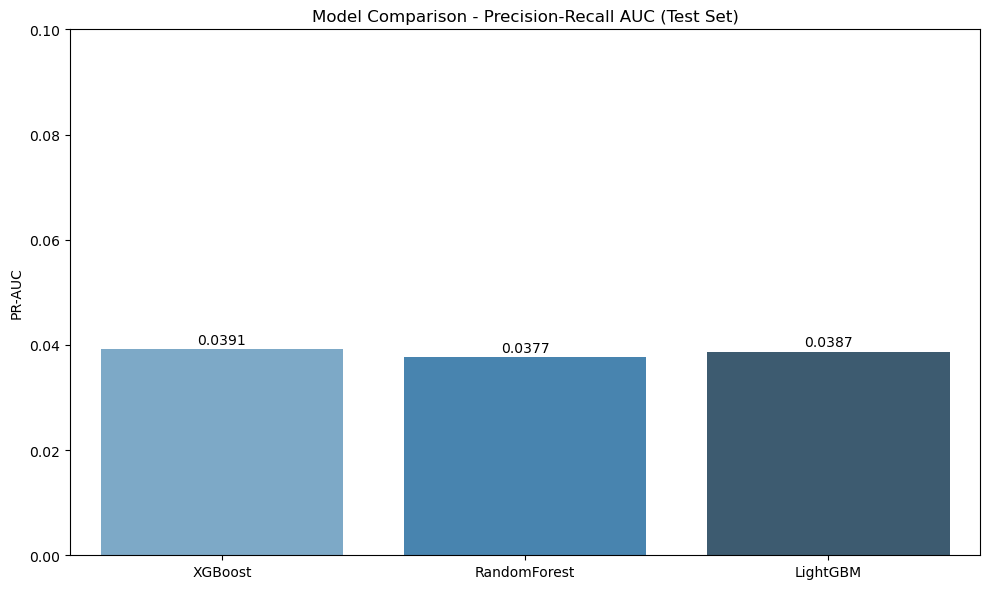

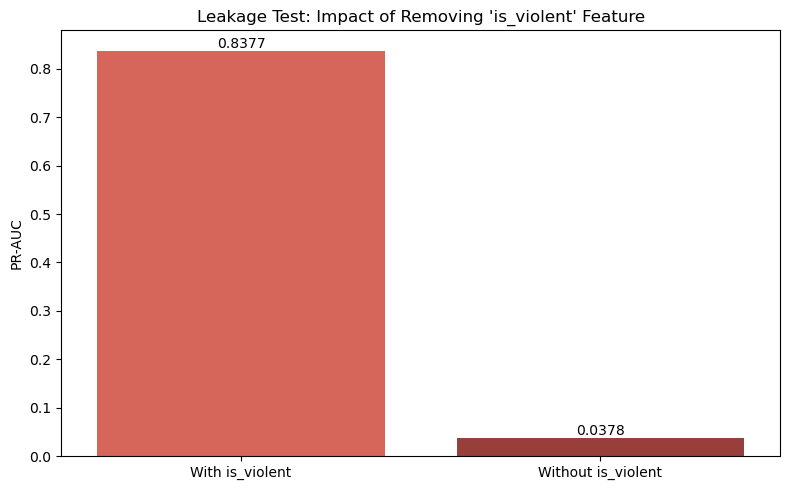

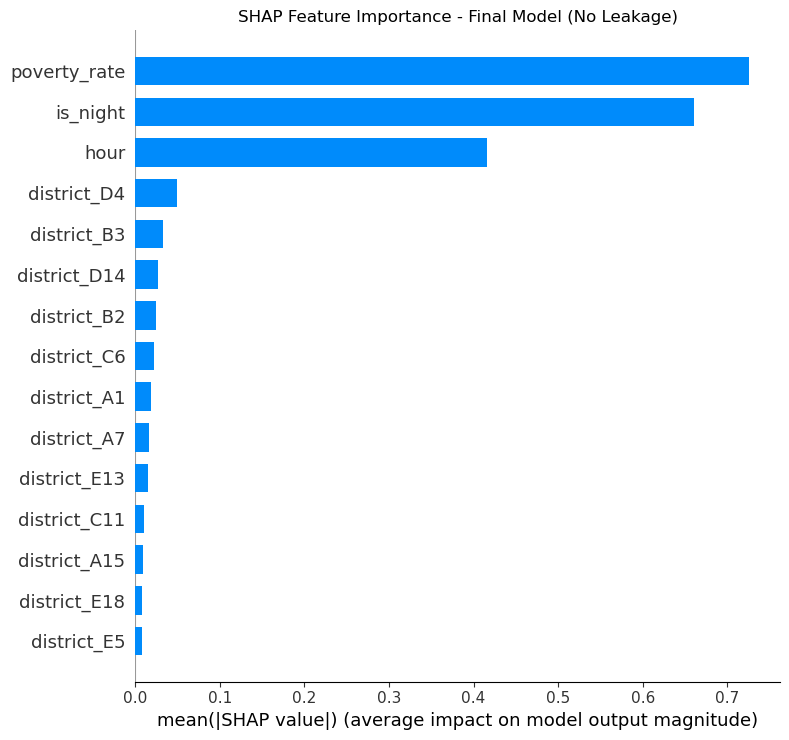


🎉 Notebook 08 completed successfully!
   Three professional plots saved in models/ folder for your final report.


In [42]:
# ================== 3 PROFESSIONAL PLOTS FOR FINAL REPORT ==================
PLOTS_DIR = REPO_ROOT / "models"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot 1: Model Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_d")
plt.title("Model Comparison - Precision-Recall AUC (Test Set)")
plt.ylabel("PR-AUC")
plt.ylim(0, 0.1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_pr_auc.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Leakage Test
leakage_results = {'With is_violent': 0.8377, 'Without is_violent': pr_auc_nl}
plt.figure(figsize=(8, 5))
sns.barplot(x=list(leakage_results.keys()), y=list(leakage_results.values()), palette="Reds_d")
plt.title("Leakage Test: Impact of Removing 'is_violent' Feature")
plt.ylabel("PR-AUC")
for i, v in enumerate(leakage_results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "leakage_test_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: SHAP Summary (Final Model)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_final, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance - Final Model (No Leakage)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_summary_final_model.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n🎉 Notebook 08 completed successfully!")
print("   Three professional plots saved in models/ folder for your final report.")